In [29]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import math

In [2]:
df_det = pd.read_parquet('/home/camarada/Documents/projects/temp-grss-nasa/daily_max_temp/forecast/apiresult/deterministic/London-Deterministic_2026-03-16-21:03.parquet')

In [3]:
df_det

,date,model,time,temperature
0,2026-03-17,ECMWF IFS HRES 9km,2026-03-17 13:00:00,14.0
1,2026-03-17,UKMO UK 2km,2026-03-17 14:00:00,14.5
2,2026-03-17,UKMO Global 10km,2026-03-17 15:00:00,14.0
3,2026-03-17,MeteoFrance ARPEGE Europe,2026-03-17 13:00:00,13.7
4,2026-03-17,DWD Germany,2026-03-17 15:00:00,14.2
5,2026-03-17,DWD ICON EU,2026-03-17 15:00:00,13.8
6,2026-03-18,ECMWF IFS HRES 9km,2026-03-18 14:00:00,16.2
7,2026-03-18,UKMO UK 2km,2026-03-18 14:00:00,16.3
8,2026-03-18,UKMO Global 10km,2026-03-18 15:00:00,15.7
9,2026-03-18,MeteoFrance ARPEGE Europe,2026-03-18 13:00:00,14.8


In [9]:
df_det.iloc[0]

date                    2026-03-17
model           ECMWF IFS HRES 9km
time           2026-03-17 13:00:00
temperature                   14.0
Name: 0, dtype: object

In [36]:
# df_det['date'] = pd.to_datetime(df_det['date'],
#                         yearfirst=True)

df_day = df_det.loc[df_det['date'] == "2026-03-17"]

In [61]:
def calc_mean_std_deterministic_forecast(temperature:np.ndarray,
                                        weights:np.ndarray):
    """
    compute mean and weighted std
    """
    # weighted mean
    mu_w = np.average(temperature,
                        weights=weights)
    
    # weight variance and std
    variance_w = np.average((temperature - mu_w)**2,
                            weights=weights
                            )
    
    # std
    std_w = np.sqrt(variance_w)

    return mu_w, std_w

In [62]:
weights_dict = {'DWD Germany':0.1,
            'DWD ICON EU':0.1,
            'ECMWF IFS HRES 9km':0.2,
            'MeteoFrance ARPEGE Europe': 0.2,
            'UKMO Global 10km':	0.1,
            'UKMO UK 2km':0.3}

## filter the df 
df_day = (df_det.loc[df_det['date'] == "2026-03-17"]).sort_values(by='model') ## import to sort! 

weights = [weights_dict[i] for i in df_day['model'].values]

mu_w, std_w = calc_mean_std_deterministic_forecast(
    temperature = df_day['temperature'].values,
    weights = weights 
)



In [69]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

def plot_forecast_distribution(mu: float, std: float, strikes: list = None):
    """
    Plots PDF and CDF together to visualize the betting landscape.
    """
    # Create range for X axis (4 standard deviations)
    x = np.linspace(mu - 4*std, mu + 4*std, 500)
    pdf = norm.pdf(x, mu, std)
    cdf = norm.cdf(x, mu, std)

    fig, ax1 = plt.subplots(figsize=(10, 6))

    # PDF Plot (Likelihood)
    ax1.plot(x, pdf, color='tab:blue', lw=2, label='PDF (Likelihood)')
    ax1.fill_between(x, pdf, color='tab:blue', alpha=0.2)
    ax1.set_xlabel('Temperature (°C)')
    ax1.set_ylabel('Density', color='tab:blue')
    ax1.tick_params(axis='y', labelcolor='tab:blue')

    # CDF Plot (Cumulative Prob)
    ax2 = ax1.twinx()
    ax2.plot(x, cdf, color='tab:red', lw=2, ls='--', label='CDF (Cumulative)')
    ax2.set_ylabel('Cumulative Probability', color='tab:red')
    ax2.tick_params(axis='y', labelcolor='tab:red')

    # Add vertical lines for market strikes if provided
    if strikes:
        for s in strikes:
            ax1.axvline(x=s, color='gray', alpha=0.5, linestyle=':')
            prob = norm.cdf(s, mu, std)
            ax2.scatter(s, prob, color='tab:red')
            ax2.annotate(f'{prob:.1%}', (s, prob), textcoords="offset points", xytext=(0,10), ha='center', color='tab:red')

    plt.title(f'Weather Market Fusion Model\n mean={mu:.2f}, std={std:.2f}')
    fig.tight_layout()
    plt.show()

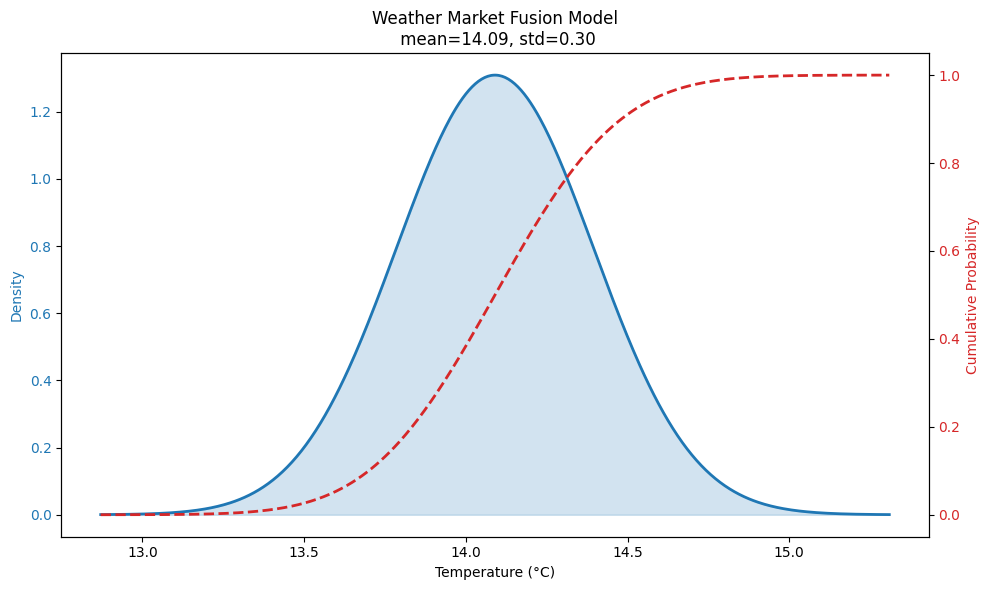

In [70]:
plot_forecast_distribution(mu_w, std_w)

In [ ]:
def calculate_market_edge(mu: float,
                         std: float,
                            bin_low: float,
                            bin_high: float,
                            market_price: float):
    """
    Calculates the probability of a specific temperature bin and the edge vs market.
    """
    # Model probability for the bin [low, high]
    model_prob = norm.cdf(bin_high, mu, std) - norm.cdf(bin_low, mu, std)
    edge = model_prob - market_price
    
    return model_prob, edge

def calculate_kelly_size(model_prob: float,
                            market_price: float,
                            kelly_fraction: float = 0.25):
    """
    Computes the Kelly Criterion fraction.
    kelly_fraction: Use 'Fractional Kelly' (e.g., 0.25) to avoid over-betting.
    """
    if model_prob <= market_price:
        return 0.0  # No edge, no bet
    
    # b = decimal odds - 1. For Polymarket, odds are 1/price
    b = (1 / market_price) - 1
    p = model_prob
    q = 1 - p
    
    f_star = (b * p - q) / b
    
    # Apply fractional Kelly (e.g., Quarter-Kelly) for safety
    return max(0, f_star * kelly_fraction)

In [76]:
calculate_kelly_size(0.38, 0.2, 0.25)

0.05625

In [ ]:
# 2. Add your "Safety Inflation" to std_w (highly recommended)
std_final = np.sqrt(std_w**2 + 0.5**2) 

# 3. Define the Polymarket you are looking at
# Example: "Will Tmax be between 14C and 15C?" priced at $0.45
strike_low, strike_high = 14.0, 15.0
current_price = 0.45

# 4. Calculate
prob, edge = calculate_market_edge(mu_w,
                                    std_final, 
                                    strike_low, strike_high, 
                                    current_price)
bet_size = calculate_kelly_size(prob, current_price, kelly_fraction=0.1) # 1/10th Kelly is safer

print(f"Model Prob: {prob:.2%}")
print(f"Edge: {edge:+.2%}")
print(f"Suggested Bet: {bet_size:.2%} of bankroll")

Model Prob: 50.10%
Edge: +5.10%
Suggested Bet: 0.93% of bankroll


### Ensemble of models

In [79]:
dfens= pd.read_parquet("/home/camarada/Documents/projects/temp-grss-nasa/daily_max_temp/forecast/apiresult/ensemble/ensemble_London_2026-03-16.parquet")

In [84]:
dfens = dfens.reset_index().rename(columns={'index':'date'})
dfens['date'] = pd.to_datetime(dfens['date'],
                                yearfirst=True)

In [87]:
dfens

,date,temperature_2m_ecmwf_ifs025_ensemble,temperature_2m_member01_ecmwf_ifs025_ensemble,temperature_2m_member02_ecmwf_ifs025_ensemble,temperature_2m_member03_ecmwf_ifs025_ensemble,temperature_2m_member04_ecmwf_ifs025_ensemble,temperature_2m_member05_ecmwf_ifs025_ensemble,temperature_2m_member06_ecmwf_ifs025_ensemble,temperature_2m_member07_ecmwf_ifs025_ensemble,temperature_2m_member08_ecmwf_ifs025_ensemble,...,temperature_2m_member10_icon_d2_eps,temperature_2m_member11_icon_d2_eps,temperature_2m_member12_icon_d2_eps,temperature_2m_member13_icon_d2_eps,temperature_2m_member14_icon_d2_eps,temperature_2m_member15_icon_d2_eps,temperature_2m_member16_icon_d2_eps,temperature_2m_member17_icon_d2_eps,temperature_2m_member18_icon_d2_eps,temperature_2m_member19_icon_d2_eps
0,2026-03-17,13.8,13.7,13.5,13.2,13.7,14.1,13.3,14.0,13.6,...,14.4,15.3,14.1,14.3,14.4,14.8,13.9,14.2,13.8,14.3
1,2026-03-18,15.6,16.7,17.8,16.5,17.1,15.4,14.6,15.4,17.1,...,15.4,17.8,17.0,16.4,16.1,15.0,16.9,16.1,16.2,17.7


In [81]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

def calculate_ensemble_distribution(member_values: np.ndarray):
    """
    Fits a KDE to the ensemble members.
    Returns the KDE object which acts as the PDF/CDF generator.

    Args:
        member_values: np.ndarray.
    """
    # Remove NaNs if any
    data = member_values[~np.isnan(member_values)]
    
    # Fit Kernel Density Estimator
    kde = gaussian_kde(data)
    
    # To get CDF from KDE, we integrate the PDF. 
    # Scipy KDE doesn't have a direct .cdf(), so we use .integrate_box_1d
    return kde

def get_kde_prob_in_bin(kde, low, high):
    """
    Returns the probability P(low < T < high) using the KDE.
    """
    return kde.integrate_box_1d(low, high)

def plot_ensemble_vs_market(kde, member_values, strikes):
    """
    Plots the actual ensemble histogram, the KDE, and the CDF.
    """
    x = np.linspace(min(member_values)-2, max(member_values)+2, 500)
    pdf_values = kde.evaluate(x)
    
    # Calculate CDF by integrating from -infinity to each x
    cdf_values = [kde.integrate_box_1d(-np.inf, val) for val in x]

    fig, ax1 = plt.subplots(figsize=(12, 6))

    # Plot Histogram of raw ensemble members
    ax1.hist(member_values, bins=30, density=True, alpha=0.3, color='gray', label='Raw Members')
    # Plot KDE PDF
    ax1.plot(x, pdf_values, color='tab:blue', lw=3, label='KDE (Model Likelihood)')
    ax1.set_ylabel('Density', color='tab:blue')

    # Plot CDF
    ax2 = ax1.twinx()
    ax2.plot(x, cdf_values, color='tab:red', lw=2, ls='--', label='CDF')
    ax2.set_ylabel('Cumulative Probability', color='tab:red')

    if strikes:
        for s in strikes:
            ax1.axvline(x=s, color='black', alpha=0.3, ls=':')
            # Label the CDF value at each strike
            p_below = kde.integrate_box_1d(-np.inf, s)
            ax2.scatter(s, p_below, color='tab:red')
            ax2.annotate(f'{p_below:.1%}', (s, p_below), xytext=(5,5), textcoords='offset points', color='red')

    plt.title("Ensemble KDE Distribution (N=217)")
    plt.show()

In [88]:
# 1. Isolate the row for the specific date
target_date = "2026-03-17"
row = dfens.loc[dfens['date']==target_date]

row

,date,temperature_2m_ecmwf_ifs025_ensemble,temperature_2m_member01_ecmwf_ifs025_ensemble,temperature_2m_member02_ecmwf_ifs025_ensemble,temperature_2m_member03_ecmwf_ifs025_ensemble,temperature_2m_member04_ecmwf_ifs025_ensemble,temperature_2m_member05_ecmwf_ifs025_ensemble,temperature_2m_member06_ecmwf_ifs025_ensemble,temperature_2m_member07_ecmwf_ifs025_ensemble,temperature_2m_member08_ecmwf_ifs025_ensemble,...,temperature_2m_member10_icon_d2_eps,temperature_2m_member11_icon_d2_eps,temperature_2m_member12_icon_d2_eps,temperature_2m_member13_icon_d2_eps,temperature_2m_member14_icon_d2_eps,temperature_2m_member15_icon_d2_eps,temperature_2m_member16_icon_d2_eps,temperature_2m_member17_icon_d2_eps,temperature_2m_member18_icon_d2_eps,temperature_2m_member19_icon_d2_eps
0,2026-03-17,13.8,13.7,13.5,13.2,13.7,14.1,13.3,14.0,13.6,...,14.4,15.3,14.1,14.3,14.4,14.8,13.9,14.2,13.8,14.3


BINGO! Market 13-14C | Prob: 42.7% | Edge: +17.7% | Bet: 4.7%


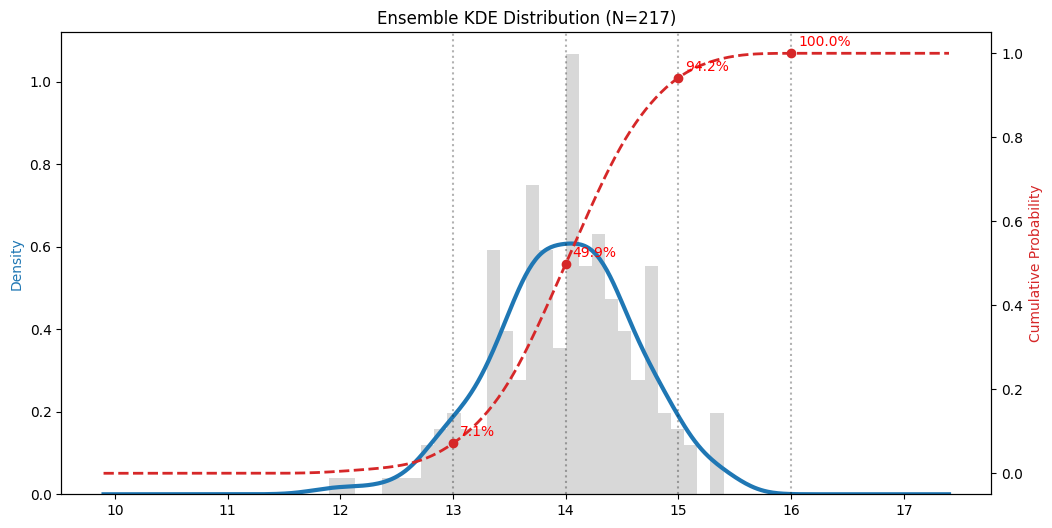

In [96]:
# filter for date 
target_date = "2026-03-17"
row = dfens.loc[dfens['date']==target_date]

# convert all member columns to a numpy array
ensemble_members = row.set_index('date').values.astype(float)

# 3. Generate the distribution
kde_model = calculate_ensemble_distribution(ensemble_members.reshape(-1))

# 4. Market Analysis Loop
markets = [
    {'bin': (13, 14), 'price': 0.25},
    {'bin': (14, 15), 'price': 0.40},
    {'bin': (15, 16), 'price': 0.20}
]

for m in markets:
    low, high = m['bin']
    price = m['price']
    
    # Calculate Edge
    prob = get_kde_prob_in_bin(kde_model, low, high)
    edge = prob - price
    
    # Calculate Kelly
    kelly = calculate_kelly_size(prob, price, kelly_fraction=0.2)
    
    if edge > 0.05:
        print(f"BINGO! Market {low}-{high}C | Prob: {prob:.1%} | Edge: {edge:+.1%} | Bet: {kelly:.1%}")

# 5. Visualize
plot_ensemble_vs_market(kde_model, ensemble_members.reshape(-1), strikes=[13, 14, 15, 16])

### Combining both models

In [97]:
def analyze_fusion_edge(mu_det:float, 
                        std_det:float, 
                        kde_ens, 
                        bin_low, 
                        bin_high, 
                        market_price):

    """
    Blends deterministic certainty with ensemble variance.

    Aegs:
        mu_det: Weighted Average of Deterministic Models
        std_det: Weighted std of deterministic models
        kde_ens = gaussian kernel class of the ensemble of models
        bin_low: the lower bin of the market
        bin_high: the upper bounder bin
        market_price: current market price at the moment 
    """
    # Deterministic
    prob_det = norm.cdf(bin_high, mu_det, std_det) - norm.cdf(bin_low, mu_det, std_det)
    
    # Ensemble Prob
    prob_ens = kde_ens.integrate_box_1d(bin_low, bin_high)
    
    # Weighted Blend (e.g., 70% Deterministic / 30% Ensemble)
    final_prob = (0.7 * prob_det) + (0.3 * prob_ens)
    
    edge = final_prob - market_price
    kelly = calculate_kelly_size(final_prob, market_price, kelly_fraction=0.15)
    
    return {
        'Final Prob': final_prob,
        'Det Contribution': prob_det,
        'Ens Contribution': prob_ens,
        'Edge': edge,
        'Kelly Bet': kelly
    }

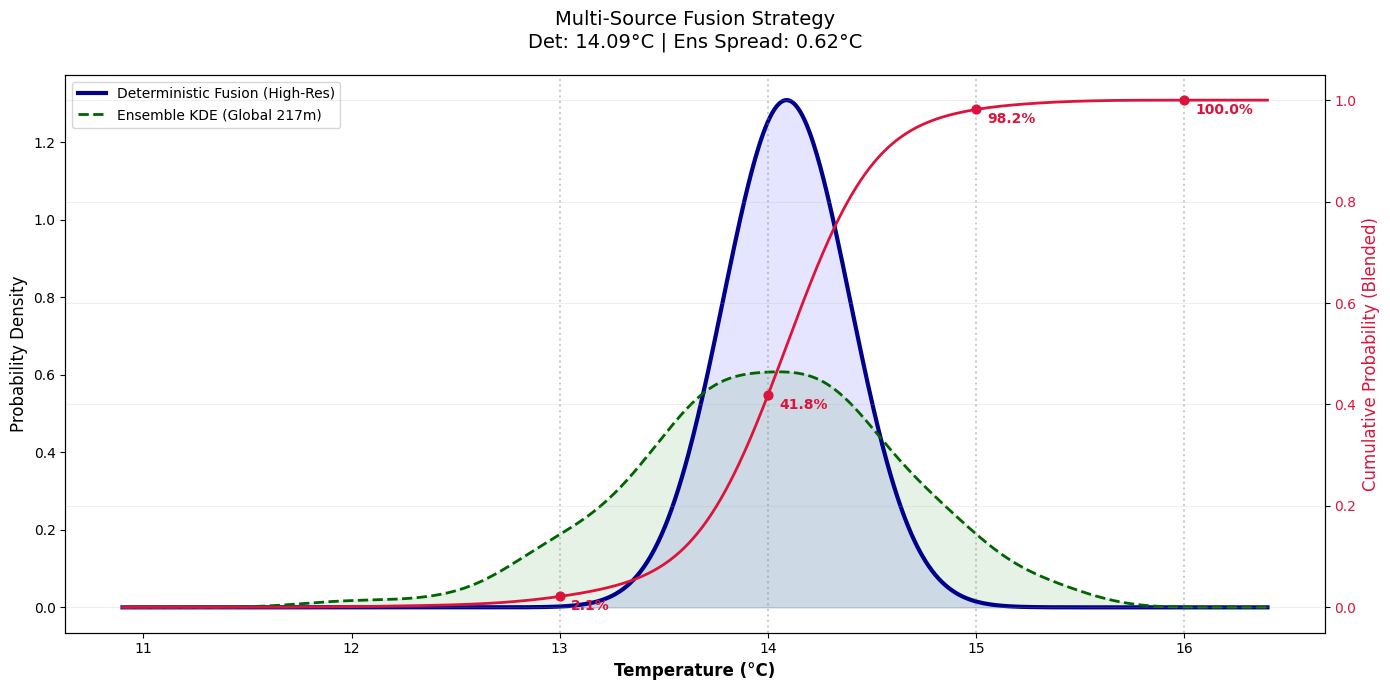

In [98]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, gaussian_kde

def plot_fusion_vs_ensemble(mu_det, std_det, kde_ens, ensemble_members, strikes=None):
    """
    Overlays the Deterministic Normal curve on top of the Ensemble KDE.
    """
    # 1. Setup X-axis range based on the full spread of data
    x_min = min(ensemble_members.min(), mu_det - 4*std_det)
    x_max = max(ensemble_members.max(), mu_det + 4*std_det)
    x = np.linspace(x_min - 1, x_max + 1, 1000)

    # 2. Calculate PDF values
    pdf_det = norm.pdf(x, mu_det, std_det)
    pdf_ens = kde_ens.evaluate(x)
    
    # 3. Calculate CDF for the blended model (70/30 Blend)
    cdf_det = norm.cdf(x, mu_det, std_det)
    cdf_ens = np.array([kde_ens.integrate_box_1d(-np.inf, val) for val in x])
    cdf_blend = (0.7 * cdf_det) + (0.3 * cdf_ens)

    # 4. Create Plot
    fig, ax1 = plt.subplots(figsize=(14, 7), dpi=100)

    # Plot Deterministic PDF (High Res)
    ax1.plot(x, pdf_det, color='darkblue', lw=3, label='Deterministic Fusion (High-Res)')
    ax1.fill_between(x, pdf_det, color='blue', alpha=0.1)

    # Plot Ensemble KDE PDF (Global Spread)
    ax1.plot(x, pdf_ens, color='darkgreen', lw=2, ls='--', label='Ensemble KDE (Global 217m)')
    ax1.fill_between(x, pdf_ens, color='green', alpha=0.1)

    ax1.set_xlabel('Temperature (°C)', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Probability Density', fontsize=12)
    ax1.legend(loc='upper left')

    # 5. Add CDF to Secondary Axis
    ax2 = ax1.twinx()
    ax2.plot(x, cdf_blend, color='crimson', lw=2, label='Blended CDF (70/30)')
    ax2.set_ylabel('Cumulative Probability (Blended)', color='crimson', fontsize=12)
    ax2.tick_params(axis='y', labelcolor='crimson')

    # 6. Add Market Strikes (1°C Bins)
    if strikes:
        for s in strikes:
            ax1.axvline(x=s, color='gray', alpha=0.4, ls=':')
            # Calculate Blended Prob at strike
            p_det = norm.cdf(s, mu_det, std_det)
            p_ens = kde_ens.integrate_box_1d(-np.inf, s)
            p_blend = (0.7 * p_det) + (0.3 * p_ens)
            
            ax2.scatter(s, p_blend, color='crimson', s=40, zorder=5)
            ax2.annotate(f'{p_blend:.1%}', (s, p_blend), xytext=(8, -10), 
                         textcoords='offset points', color='crimson', fontweight='bold')

    plt.title(f'Multi-Source Fusion Strategy\nDet: {mu_det:.2f}°C | Ens Spread: {ensemble_members.std():.2f}°C', 
              fontsize=14, pad=20)
    plt.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()

# --- EXAMPLE EXECUTION ---
plot_fusion_vs_ensemble(mu_w, std_w, kde_model, ensemble_members, strikes=[13, 14, 15, 16])